# 05 — Validation error analysis

Accuracy tells us **how often** the saved model was correct. This notebook asks **where and how** it was wrong. We load the exact epoch-5 checkpoint, inspect only the validation split, and keep the official test split untouched.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

BATCH_SIZE = 16
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SELECTED_CLASSES = ['Abyssinian', 'Bengal', 'Egyptian Mau']

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')

PyTorch: 2.13.0+cpu
Device:  cpu


In [2]:
CURRENT_FOLDER = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_FOLDER if (CURRENT_FOLDER / 'pyproject.toml').exists() else CURRENT_FOLDER.parent
METADATA_PATH = PROJECT_ROOT / 'data' / 'classification_crops' / 'metadata.csv'
CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'part2_resnet18_frozen_head_epoch5.pt'

assert METADATA_PATH.exists(), f'Missing crop metadata: {METADATA_PATH}'
assert CHECKPOINT_PATH.exists(), f'Missing checkpoint: {CHECKPOINT_PATH}'
records = pd.read_csv(METADATA_PATH)
val_records = records.query("split == 'val'").reset_index(drop=True)

assert len(val_records) == 58
assert set(val_records['class_name']) == set(SELECTED_CLASSES)
display(val_records.groupby('class_name').size().rename('validation_examples').to_frame())
print('Only validation records are loaded below. Test records remain unused.')

,validation_examples
class_name,
Abyssinian,20
Bengal,20
Egyptian Mau,18


Only validation records are loaded below. Test records remain unused.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PetCropDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image_path = PROJECT_ROOT / row['crop_path']
        with Image.open(image_path) as image:
            image = image.convert('RGB')
        return self.transform(image), int(row['label_id'])

val_loader = DataLoader(PetCropDataset(val_records, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f'Validation batches: {len(val_loader)}')
print('shuffle=False keeps prediction order matched to the metadata rows.')

Validation batches: 4
shuffle=False keeps prediction order matched to the metadata rows.


## Reload the saved model

We rebuild the same ResNet18 shape, then put the saved numbers back into it. `weights=None` is deliberate: the checkpoint already contains the required weights, so nothing needs downloading.

In [4]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
assert checkpoint['class_names'] == SELECTED_CLASSES

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(SELECTED_CLASSES))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(checkpoint['training_setup'])
print(f"Saved epochs: {len(checkpoint['history'])}")
print('Checkpoint loaded successfully. eval() means prediction mode: no weights will change.')

ResNet18 pretrained; feature extractor frozen; final layer trained for 5 epochs
Saved epochs: 5
Checkpoint loaded successfully. eval() means prediction mode: no weights will change.


In [5]:
all_true_ids, all_predicted_ids, all_probabilities = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images.to(DEVICE))
        probabilities = torch.softmax(logits, dim=1)
        all_true_ids.extend(labels.tolist())
        all_predicted_ids.extend(probabilities.argmax(dim=1).cpu().tolist())
        all_probabilities.extend(probabilities.cpu().tolist())

results = val_records[['image_id', 'class_name', 'label_id', 'crop_path']].copy()
results = results.rename(columns={'class_name': 'true_class', 'label_id': 'true_id'})
results['predicted_id'] = all_predicted_ids
results['predicted_class'] = [SELECTED_CLASSES[class_id] for class_id in all_predicted_ids]
results['correct'] = results['true_id'] == results['predicted_id']
for class_id, class_name in enumerate(SELECTED_CLASSES):
    results[f'P({class_name})'] = [row[class_id] for row in all_probabilities]

assert len(results) == len(val_records)
assert results['correct'].mean() == (np.array(all_true_ids) == np.array(all_predicted_ids)).mean()
display(results.head().round(3))

,image_id,true_class,true_id,crop_path,predicted_id,predicted_class,correct,P(Abyssinian),P(Bengal),P(Egyptian Mau)
0,Abyssinian_101,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,1,Bengal,False,0.438,0.480,0.082
1,Abyssinian_102,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,0,Abyssinian,True,0.519,0.201,0.281
2,Abyssinian_11,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,0,Abyssinian,True,0.778,0.062,0.160
3,Abyssinian_113,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,0,Abyssinian,True,0.541,0.020,0.439
4,Abyssinian_119,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,0,Abyssinian,True,0.622,0.215,0.162


In [6]:
validation_accuracy = results['correct'].mean()
correct_count = int(results['correct'].sum())
error_count = len(results) - correct_count

print(f'Validation accuracy: {validation_accuracy:.1%} ({correct_count}/{len(results)} correct)')
print(f'Validation errors:   {error_count}')
print('This should reproduce the epoch-5 validation result from Notebook 4.')

Validation accuracy: 81.0% (47/58 correct)
Validation errors:   11
This should reproduce the epoch-5 validation result from Notebook 4.


## Confusion matrix

Each row is the real class; each column is the model prediction. Good results appear on the diagonal from top-left to bottom-right. An off-diagonal number tells us a specific mix-up.

predicted class,Abyssinian,Bengal,Egyptian Mau
true class,,,
Abyssinian,19,1,0
Bengal,3,13,4
Egyptian Mau,3,0,15


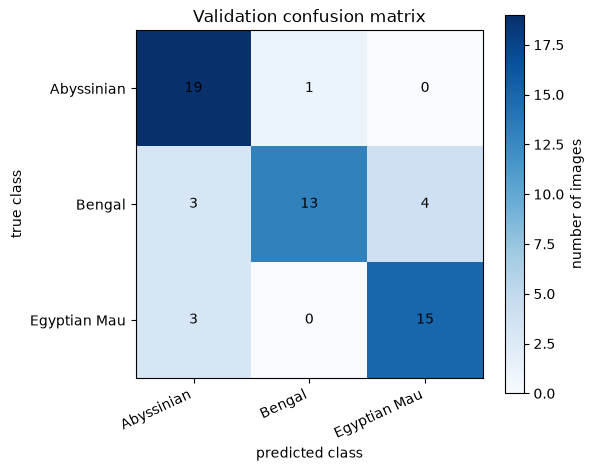

In [7]:
confusion = pd.crosstab(
    pd.Categorical(results['true_class'], categories=SELECTED_CLASSES),
    pd.Categorical(results['predicted_class'], categories=SELECTED_CLASSES),
    rownames=['true class'],
    colnames=['predicted class'],
    dropna=False,
)
display(confusion)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion.to_numpy(), cmap='Blues')
ax.set(xticks=range(3), yticks=range(3), xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES, xlabel='predicted class', ylabel='true class', title='Validation confusion matrix')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
for row in range(3):
    for column in range(3):
        ax.text(column, row, confusion.iloc[row, column], ha='center', va='center')
fig.colorbar(image, ax=ax, label='number of images')
plt.tight_layout()
plt.show()

In [8]:
per_class_rows = []
for class_name in SELECTED_CLASSES:
    true_positive = int(((results['true_class'] == class_name) & (results['predicted_class'] == class_name)).sum())
    false_positive = int(((results['true_class'] != class_name) & (results['predicted_class'] == class_name)).sum())
    false_negative = int(((results['true_class'] == class_name) & (results['predicted_class'] != class_name)).sum())
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    per_class_rows.append({'class': class_name, 'precision': precision, 'recall': recall, 'f1': f1, 'support': true_positive + false_negative})

per_class = pd.DataFrame(per_class_rows).set_index('class')
display(per_class.round(3))
print('Precision asks: when the model predicts this class, how often is it right?')
print('Recall asks: of the real images in this class, how many did the model find?')

,precision,recall,f1,support
class,,,,
Abyssinian,0.760,0.950,0.844,20
Bengal,0.929,0.650,0.765,20
Egyptian Mau,0.789,0.833,0.811,18


Precision asks: when the model predicts this class, how often is it right?
Recall asks: of the real images in this class, how many did the model find?


## Look at the mistakes

The table and images are more useful than guessing why a model failed. A probability near 0.50 versus 0.45 shows uncertainty; a high incorrect probability suggests the model was confidently wrong.

In [9]:
errors = results.loc[~results['correct']].copy()
probability_columns = [f'P({class_name})' for class_name in SELECTED_CLASSES]
error_probability_matrix = errors[probability_columns].to_numpy()
errors['predicted_probability'] = error_probability_matrix[np.arange(len(errors)), errors['predicted_id'].to_numpy()]
errors = errors.sort_values('predicted_probability', ascending=False)
display(errors[['image_id', 'true_class', 'predicted_class', 'predicted_probability', *probability_columns]].round(3))
print(f'{len(errors)} validation mistakes are shown above; none are test images.')

,image_id,true_class,predicted_class,predicted_probability,P(Abyssinian),P(Bengal),P(Egyptian Mau)
51,Egyptian_Mau_155,Egyptian Mau,Abyssinian,0.756,0.756,0.140,0.104
35,Bengal_166,Bengal,Egyptian Mau,0.718,0.192,0.090,0.718
39,Bengal_189,Bengal,Egyptian Mau,0.652,0.074,0.274,0.652
33,Bengal_156,Bengal,Egyptian Mau,0.648,0.058,0.294,0.648
52,Egyptian_Mau_172,Egyptian Mau,Abyssinian,0.544,0.544,0.216,0.240
0,Abyssinian_101,Abyssinian,Bengal,0.480,0.438,0.480,0.082
34,Bengal_165,Bengal,Egyptian Mau,0.459,0.354,0.187,0.459
32,Bengal_143,Bengal,Abyssinian,0.450,0.450,0.377,0.172
23,Bengal_110,Bengal,Abyssinian,0.442,0.442,0.439,0.119
50,Egyptian_Mau_154,Egyptian Mau,Abyssinian,0.418,0.418,0.253,0.329


11 validation mistakes are shown above; none are test images.


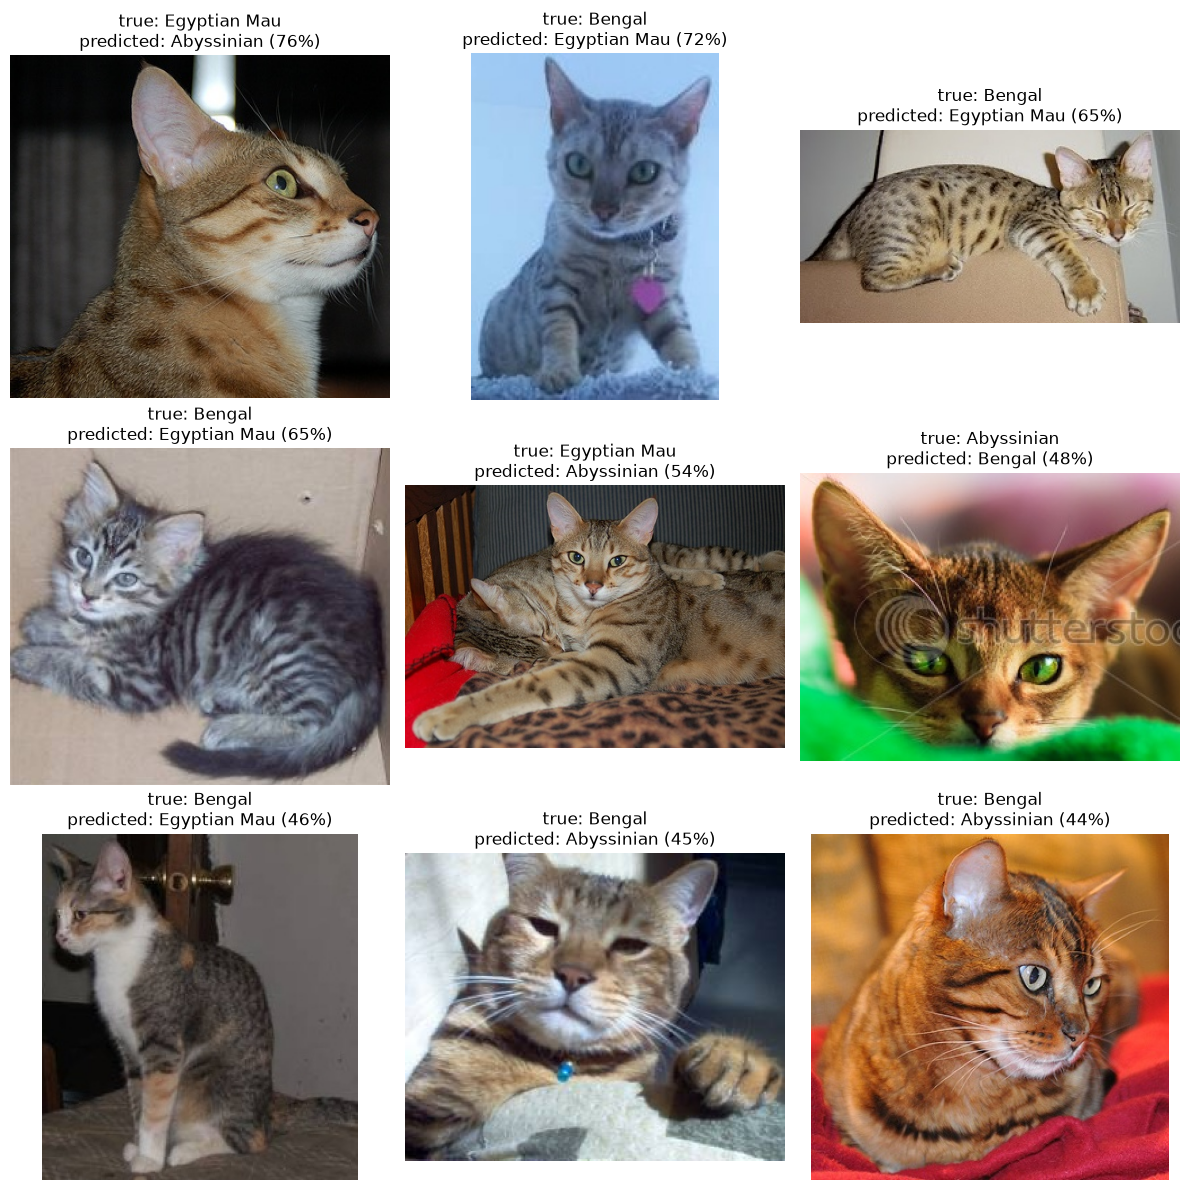

In [10]:
MAX_TO_SHOW = 9
examples = errors.head(MAX_TO_SHOW).reset_index(drop=True)
if examples.empty:
    print('No validation errors to display.')
else:
    columns = 3
    rows = int(np.ceil(len(examples) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, examples.iterrows()):
        with Image.open(PROJECT_ROOT / row['crop_path']) as image:
            ax.imshow(image.convert('RGB'))
        ax.set_title(f"true: {row['true_class']}\npredicted: {row['predicted_class']} ({row['predicted_probability']:.0%})")
        ax.axis('off')
    for ax in axes[len(examples):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### Stop and interpret

Send the accuracy, confusion matrix, per-class table, and error-image plot. We will use the validation evidence—not the test set—to decide the next experiment.